# NYC Yellow Taxi Data Visualisation – November 2024

## ->Project Overview

The dataset used in this analysis is the November 2024 Yellow Taxi Trip Records published by the New York City Taxi and Limousine Commission (NYC TLC, 2024).

This project presents an explanatory data analysis of the **NYC Yellow Taxi Trip Records for November 2024**. The aim is to explore taxi trip data and identify meaningful patterns that can be communicated through clear and appropriate data visualisations.

The analysis will begin by exploring the structure and quality of the dataset, followed by basic data cleaning and preprocessing where required. The cleaned data will then be analysed to identify interesting insights related to taxi journeys, such as trip activity, distance, fares, payment behaviour, and other relevant patterns.

## ->Business and visualisation context

The NYC Yellow Taxi dataset contains detailed information about taxi trips, including pickup and drop-off times, trip distance, passenger count, fares, tips, payment information, and other trip-related attributes. This provides an opportunity to understand how yellow taxi services are used and to identify patterns within taxi operations.

For this analysis, the intended audience is taxi service and operations management. The aim is to provide the audience with a clearer understanding of travel patterns, customer behaviour, and financial characteristics of taxi trips during November 2024. These findings could support decisions related to service planning, demand management, and operational performance.

The analysis will use the available trip data to answer questions such as when taxi activity is highest, how trip distances and fares are distributed, how payment behaviour differs between trips, and whether meaningful relationships exist between variables such as distance, fare, and tips.

The final visualisations will focus on selected findings that are useful and meaningful to the intended audience rather than presenting every pattern found during the exploratory analysis.


The project will follow the following stages:

1. **Data Exploration** – Understand the dataset, its variables, data types, and potential data quality issues.
2. **Data Preprocessing** – Clean and prepare the data for analysis.
3. **Data Visualisation and Insights** – Create visualisations to investigate and communicate meaningful patterns in the data.
4. **Discussion and Conclusion** – Summarise the main findings, limitations, business implications, and recommendations.

## Step 1: Data exploration

#### 1.1 IMPORTING LIBRARIES AND DATASET

In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("yellow_tripdata_2024-11.parquet")



In [2]:
## checking whether the dataset is loaded properly or not

df.head(20)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-11-01 00:46:24,2024-11-01 00:57:17,1.0,1.93,1.0,N,239,262,2,-12.8,-1.0,-0.5,0.00,0.00,-1.0,-17.80,-2.5,0.00
1,2,2024-11-01 00:46:24,2024-11-01 00:57:17,1.0,1.93,1.0,N,239,263,2,12.8,1.0,0.5,0.00,0.00,1.0,17.80,2.5,0.00
2,1,2024-11-01 00:37:36,2024-11-01 01:28:36,1.0,34.30,5.0,N,219,265,1,259.0,0.0,0.0,15.00,0.00,1.0,275.00,0.0,0.00
3,2,2024-11-01 00:12:55,2024-11-01 00:22:17,2.0,0.93,1.0,N,186,107,1,10.0,1.0,0.5,1.00,0.00,1.0,16.00,2.5,0.00
4,2,2024-11-01 00:54:45,2024-11-01 00:59:47,1.0,0.38,1.0,N,79,79,1,6.5,1.0,0.5,1.00,0.00,1.0,12.50,2.5,0.00
5,2,2024-11-01 00:19:00,2024-11-01 00:21:28,1.0,0.48,1.0,N,237,236,2,5.1,1.0,0.5,0.00,0.00,1.0,10.10,2.5,0.00
6,2,2024-11-01 00:42:45,2024-11-01 00:56:23,2.0,2.61,1.0,N,43,116,1,14.9,1.0,0.5,3.00,0.00,1.0,20.40,0.0,0.00
7,2,2024-11-01 00:30:10,2024-11-01 00:37:28,1.0,2.52,1.0,N,239,41,1,12.1,1.0,0.5,3.42,0.00,1.0,20.52,2.5,0.00
8,2,2024-11-01 00:44:14,2024-11-01 00:49:12,1.0,1.12,1.0,N,166,238,1,7.9,1.0,0.5,2.08,0.00,1.0,12.48,0.0,0.00
9,2,2024-11-01 00:05:05,2024-11-01 00:13:12,2.0,0.74,1.0,N,107,234,1,8.6,1.0,0.5,2.72,0.00,1.0,16.32,2.5,0.00


In [3]:
## in this cell we simply check how many rows and columns are there and their names and data types; also which missing values are present

df.shape
df.columns

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3646369 entries, 0 to 3646368
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

#### 1.2 Data understanding
 IN THE FOLLOWING THREE CELLS WE WILL DISCOVER THE DESCRIPTIVE STATISTICS, FIND MISSING VALUES AND DUPLICATES

In [4]:


df.describe()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,3.646369e+06,3646369,3646369,3.272695e+06,3.646369e+06,3.272695e+06,3.646369e+06,3.646369e+06,3.646369e+06,3.646369e+06,3.646369e+06,3.646369e+06,3.646369e+06,3.646369e+06,3.646369e+06,3.646369e+06,3.272695e+06,3.272695e+06
mean,1.768085e+00,2024-11-15 17:27:55.648361,2024-11-15 17:45:42.936777,1.328072e+00,5.369541e+00,2.358266e+00,1.646220e+02,1.638229e+02,1.099045e+00,1.919806e+01,1.311295e+00,4.778865e-01,3.315194e+00,5.389581e-01,9.562768e-01,2.765202e+01,2.237168e+00,1.345813e-01
min,1.000000e+00,2002-12-31 22:17:43,2002-12-31 22:23:55,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-1.458300e+03,-7.500000e+00,-5.000000e-01,-9.368000e+01,-1.406300e+02,-1.000000e+00,-1.477680e+03,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-11-08 16:43:32,2024-11-08 17:05:55,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.580000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-11-15 19:11:36,2024-11-15 19:28:02,1.000000e+00,1.720000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.420000e+01,1.000000e+00,5.000000e-01,2.650000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-11-22 16:02:55,2024-11-22 16:23:55,1.000000e+00,3.290000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.260000e+01,2.500000e+00,5.000000e-01,4.260000e+00,0.000000e+00,1.000000e+00,3.050000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2024-12-01 22:04:33,2024-12-01 23:10:54,9.000000e+00,3.986086e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,3.355444e+05,1.425000e+01,4.130000e+01,5.725000e+02,1.406300e+02,1.000000e+00,3.355509e+05,2.500000e+00,1.750000e+00
std,4.235017e-01,NaN,NaN,7.827830e-01,5.386895e+02,1.108511e+01,6.455048e+01,6.945364e+01,6.601429e-01,1.767556e+02,1.768704e+00,1.379477e-01,4.068223e+00,2.175929e+00,2.736093e-01,1.773279e+02,8.831225e-01,4.855642e-01


In [5]:
df.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          373674
trip_distance                 0
RatecodeID               373674
store_and_fwd_flag       373674
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     373674
Airport_fee              373674
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

### 1.3 Identifying Data Quality Issues

Pandas was used to explore, manipulate and preprocess the taxi dataset before conducting the visual analysis (McKinney, 2022).


The initial exploration identified several data quality issues that should be considered before visualising the data. Some columns contain missing values, particularly passenger count, RatecodeID, store-and-forward flag, congestion surcharge, and airport fee.

The descriptive statistics also indicate potentially invalid or extreme observations. These include pickup dates outside November 2024, negative fare amounts, zero passenger counts, and unusually large trip distances. These observations could distort the visualisations and therefore require further investigation before the data is cleaned.

In [7]:
df["tpep_pickup_datetime"].min(), df["tpep_pickup_datetime"].max()

(Timestamp('2002-12-31 22:17:43'), Timestamp('2024-12-01 22:04:33'))

In [8]:
## FIGURING OUT HOW MANY RECORDS ARE OUTSIDE NOVEMBER 2024

outside_november = df[
    (df["tpep_pickup_datetime"] < "2024-11-01") |
    (df["tpep_pickup_datetime"] >= "2024-12-01")
]

outside_november.shape

(50, 19)

In [9]:
(df["trip_distance"] <= 0).sum()

np.int64(68315)

In [10]:
(df["fare_amount"] < 0).sum()

np.int64(71470)

In [11]:
df["passenger_count"].value_counts().sort_index()

passenger_count
0.0      28370
1.0    2527941
2.0     492151
3.0     114165
4.0      73766
5.0      21282
6.0      14999
7.0          4
8.0         14
9.0          3
Name: count, dtype: int64

## Step 2. Data Preprocessing

Based on the initial exploration, several data quality issues were identified. The dataset will now be cleaned to improve the reliability of the subsequent analysis and visualisations.

The cleaning process focuses on records relevant to the analysis. Trips outside November 2024 will be removed, along with trips containing zero or negative distances and negative fare amounts. Missing values will be handled according to whether the affected variables are required for a particular analysis.

### 2.1 Limiting only to November '24  

In [12]:
df_clean = df[
    (df["tpep_pickup_datetime"] >= "2024-11-01") &
    (df["tpep_pickup_datetime"] < "2024-12-01")
].copy()

In [13]:
df_clean.shape

(3646319, 19)

In [14]:
##removing zero/negative trip distance and negative fare amount 

df_clean = df_clean[df_clean["trip_distance"] > 0]
df_clean = df_clean[df_clean["fare_amount"] >= 0]

In [15]:
df_clean.shape

(3511771, 19)

In [16]:
(df_clean["trip_distance"] <= 0).sum()
(df_clean["fare_amount"] < 0).sum()

np.int64(0)

### 2.2 Checking Extreme Values

After removing invalid records, the numerical variables are checked again for unusually large values that could distort the analysis and visualisations.

In [17]:
df_clean[["trip_distance", "fare_amount", "total_amount"]].describe()

,trip_distance,fare_amount,total_amount
count,3.511771e+06,3.511771e+06,3.511771e+06
mean,5.272184e+00,1.983752e+01,2.858142e+01
std,5.041084e+02,1.799239e+02,1.804268e+02
min,1.000000e-02,0.000000e+00,-5.750000e+00
25%,1.040000e+00,9.300000e+00,1.610000e+01
50%,1.760000e+00,1.420000e+01,2.136000e+01
75%,3.330000e+00,2.260000e+01,3.069000e+01
max,3.986086e+05,3.355444e+05,3.355509e+05


In [18]:
df_clean["trip_distance"].sort_values(ascending=False).head(10)

3630276    398608.62
3494582    324219.56
3589018    272044.78
3281163    234549.19
3509990    183507.04
3403339    174109.40
3581909    172686.83
3413812    124548.05
3320114    122613.76
3429019    116678.81
Name: trip_distance, dtype: float64

In [19]:
df_clean["fare_amount"].sort_values(ascending=False).head(10)

66603      335544.44
1608067      5906.84
553716       1458.30
373438        924.20
2964885       900.00
2964884       900.00
3030730       870.00
1812874       777.90
3088394       769.50
2935301       756.20
Name: fare_amount, dtype: float64

### 2.3 Discovering the Upper Range


The descriptive statistics show a large difference between typical trip values and the maximum recorded values. To better understand these extreme observations, the 99th percentile of trip distance and fare amount is examined. This helps determine the range in which the majority of taxi trips fall before deciding how extreme values should be handled.

In [20]:
df_clean["trip_distance"].quantile(0.99)

np.float64(19.92)

In [21]:
df_clean["fare_amount"].quantile(0.99)

np.float64(77.25599999999628)

In [22]:
distance_99 = df_clean["trip_distance"].quantile(0.99)
fare_99 = df_clean["fare_amount"].quantile(0.99)

distance_99, fare_99

(np.float64(19.92), np.float64(77.25599999999628))

In [23]:
(df_clean["trip_distance"] > distance_99).sum()

np.int64(35090)

In [24]:
(df_clean["fare_amount"] > fare_99).sum()

np.int64(35118)

The 99th percentile shows that 99% of trip distances are approximately 19.92 miles or below, while 99% of fare amounts are approximately $77.26 or below. This confirms that the extremely large maximum values are not representative of typical taxi trips.

However, observations above the 99th percentile are not automatically removed, as some may represent legitimate long-distance or high-fare journeys. Instead, extreme values will be considered when constructing individual visualisations so that they do not distort the presentation of typical trip patterns.

## 3. Data Visualisation and Insights

This section uses the cleaned dataset to explore patterns in NYC Yellow Taxi trips during November 2024. The purpose is to identify meaningful findings and communicate them using appropriate visualisations.

Matplotlib and Seaborn were used to create the visualisations presented in this analysis. Matplotlib provides tools for constructing and customising graphical visualisations (Hunter, 2007), while Seaborn was used for statistical visualisations such as distributions, box plots and heatmaps (Waskom, 2021).

The analysis focuses on patterns that may be useful for understanding taxi demand, trip characteristics, fares, payment behaviour, and customer activity. Each selected insight will be supported by a visualisation and an interpretation of its relevance.

### 3.1 Preparing Time-Based Variables

To analyse when taxi trips occur, the pickup timestamp is used to create two additional variables: the pickup hour and the day of the week. These variables will allow taxi activity to be compared across different times and days.

In [25]:
df_clean["pickup_hour"] = df_clean["tpep_pickup_datetime"].dt.hour
df_clean["pickup_day"] = df_clean["tpep_pickup_datetime"].dt.day_name()

In [26]:
df_clean[["tpep_pickup_datetime", "pickup_hour", "pickup_day"]].head()

,tpep_pickup_datetime,pickup_hour,pickup_day
1,2024-11-01 00:46:24,0,Friday
2,2024-11-01 00:37:36,0,Friday
3,2024-11-01 00:12:55,0,Friday
4,2024-11-01 00:54:45,0,Friday
5,2024-11-01 00:19:00,0,Friday


### 3.2 INSIGHTS 

#### Insight 1 : WHEN ARE YELLOW TAXIS USED THE MOST?


In [27]:
trips_by_hour = df_clean["pickup_hour"].value_counts().sort_index()

trips_by_hour

pickup_hour
0     100328
1      70990
2      44516
3      29702
4      21895
5      24382
6      49990
7      97256
8     130763
9     145030
10    158585
11    171801
12    186667
13    193634
14    208866
15    219182
16    222631
17    239290
18    247495
19    216785
20    199493
21    201225
22    185784
23    145481
Name: count, dtype: int64

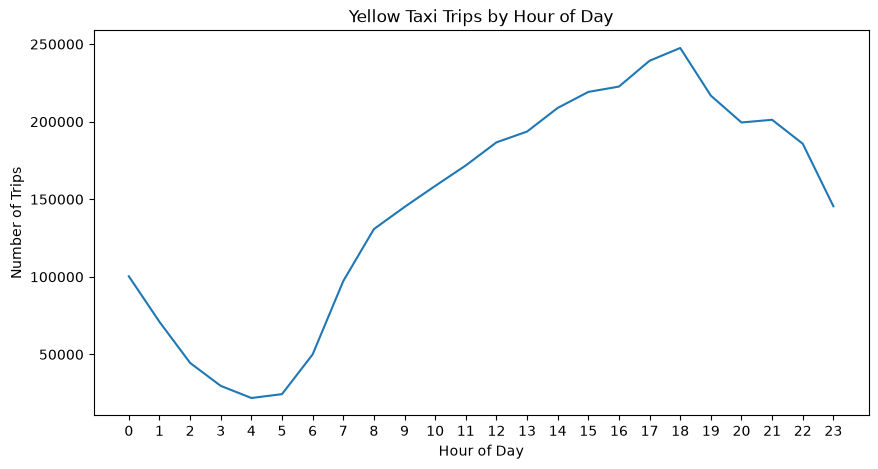

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(trips_by_hour.index, trips_by_hour.values)

plt.title("Yellow Taxi Trips by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))

plt.show()

#### Interpretation

The visualisation shows a clear daily pattern in Yellow Taxi activity. Trip numbers are lowest during the early morning hours, reaching their minimum at approximately 4:00 AM with 21,895 trips. Activity then increases considerably from around 6:00 AM and continues to rise throughout most of the day.

The highest level of activity occurs at 6:00 PM (18:00), with 247,495 recorded trips. After this peak, the number of trips gradually decreases during the evening.

This pattern suggests that taxi demand is considerably stronger during the daytime and early evening than during the early morning. For taxi operations management, the results could help identify periods when greater driver availability may be required, particularly during the late afternoon and early evening.

#### Insight 2: Which days have the highest taxi demand


Taxi demand may vary across different days of the week. Understanding these differences can help identify whether taxi usage is stronger on weekdays or weekends and may support decisions related to driver availability and service planning.

In [29]:
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

trips_by_day = df_clean["pickup_day"].value_counts().reindex(day_order)

trips_by_day

pickup_day
Monday       403329
Tuesday      447652
Wednesday    471456
Thursday     483082
Friday       615076
Saturday     639092
Sunday       452084
Name: count, dtype: int64

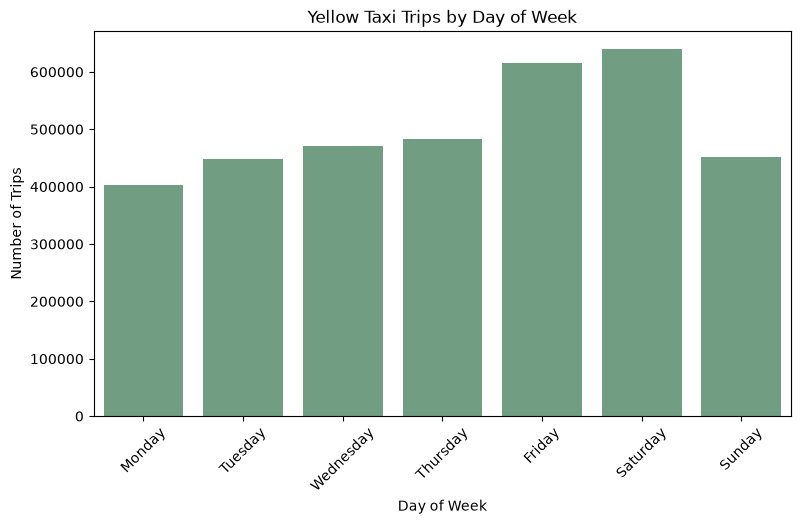

In [30]:
day_data = trips_by_day.reset_index()
day_data.columns = ["Day", "Trips"]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=day_data,
    x="Day",
    y="Trips",
    color="#69A682"
)

plt.title("Yellow Taxi Trips by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)

plt.show()

#### Interpretation

Taxi demand varies noticeably across the days of the week. Saturday records the highest number of trips with 639,092 journeys, followed by Friday with 615,076 trips. In comparison, Monday has the lowest activity with 403,329 trips.

The results show a particularly strong increase in taxi usage towards Friday and Saturday, while demand falls again on Sunday. This suggests that Yellow Taxi usage is especially strong towards the end of the working week and the beginning of the weekend.

From an operational perspective, taxi service providers could consider greater driver availability on Fridays and Saturdays to respond to the higher level of demand observed on these days.



### Insight 3: What Distances Are Most Yellow Taxi Trips?

Understanding the distribution of trip distances provides insight into how customers typically use Yellow Taxis. This can help distinguish whether the service is primarily used for shorter urban journeys or longer-distance travel.

The earlier preprocessing stage identified extreme trip-distance values. Therefore, this visualisation focuses on trips within the 99th percentile of the distance distribution (19.92 miles) to prevent extreme observations from distorting the visual representation.

In [31]:
## creating data and checking it 

distance_data = df_clean[df_clean["trip_distance"] <= distance_99]
distance_data["trip_distance"].describe()

count    3.476681e+06
mean     3.133688e+00
std      3.786909e+00
min      1.000000e-02
25%      1.030000e+00
50%      1.740000e+00
75%      3.240000e+00
max      1.992000e+01
Name: trip_distance, dtype: float64

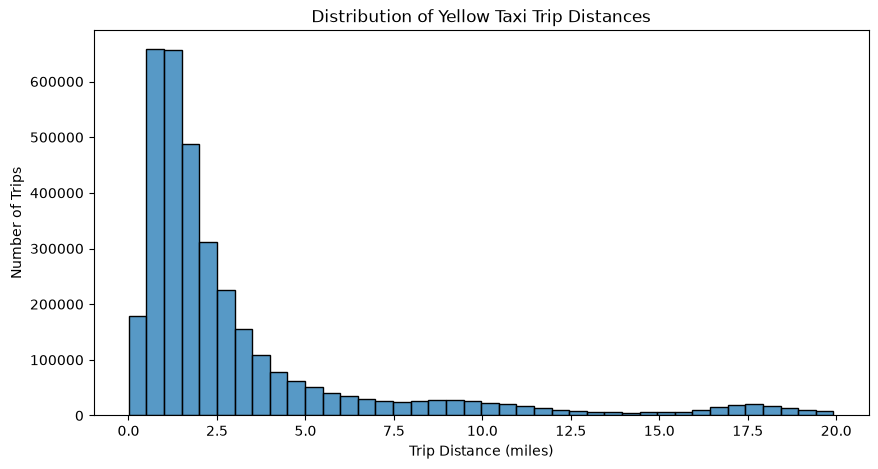

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(data=distance_data, x="trip_distance", bins=40)

plt.title("Distribution of Yellow Taxi Trip Distances")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")

plt.show()

#### Interpretation

The histogram shows that Yellow Taxi trip distances are strongly right-skewed. Most trips are concentrated within approximately 1–3 miles, with the number of journeys decreasing considerably as trip distance increases.

This indicates that Yellow Taxis are used predominantly for shorter journeys rather than long-distance travel. Although some longer trips are present, they represent a much smaller proportion of overall taxi activity.

From a business perspective, this suggests that a substantial part of Yellow Taxi operations depends on frequent short-distance journeys. Understanding this pattern can help operators recognise the typical travel behaviour of customers and the types of trips that contribute most frequently to taxi activity.

###  Insight 4: How Does Trip Distance Relate to Fare Amount?

Trip distance is expected to be an important factor in determining the fare charged for a taxi journey. Examining the relationship between these two variables can show whether longer journeys generally result in higher fares and whether this relationship is consistent across trips.

To prevent previously identified extreme values from distorting the visualisation, the analysis focuses on trip distances and fare amounts within their respective 99th percentile ranges.

In [33]:
fare_distance_data = df_clean[
    (df_clean["trip_distance"] <= distance_99) &
    (df_clean["fare_amount"] <= fare_99)
]

fare_distance_data[["trip_distance", "fare_amount"]].head()

,trip_distance,fare_amount
1,1.93,12.8
3,0.93,10.0
4,0.38,6.5
5,0.48,5.1
6,2.61,14.9


In [34]:
## we take a random sample of 10,000 records from the fare_distance_data for visualization purposes because there are over 3 million records in the dataset, and plotting all of them would be inefficient and cluttered. By sampling, we can visualize the relationship between trip distance and fare amount more clearly while still maintaining a representative subset of the data.

fare_distance_sample = fare_distance_data.sample(10000, random_state=42)

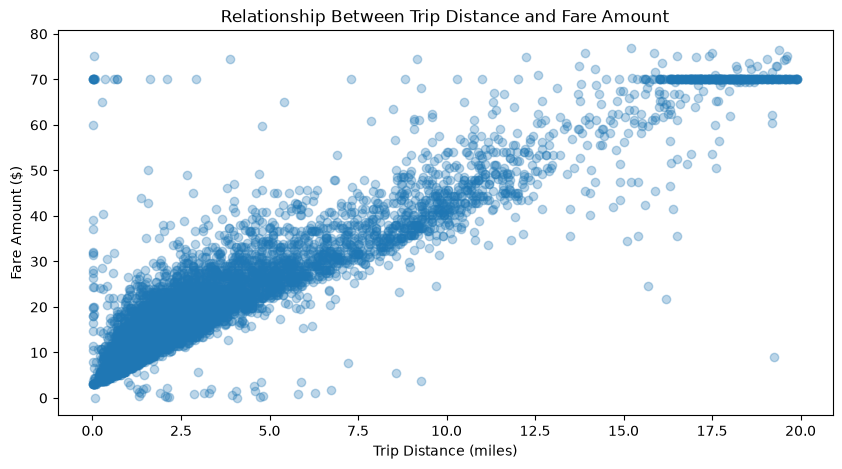

In [35]:
plt.figure(figsize=(10, 5))

plt.scatter(
    fare_distance_sample["trip_distance"],
    fare_distance_sample["fare_amount"],
    alpha=0.3
)

plt.title("Relationship Between Trip Distance and Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")

plt.show()

#### Interpretation

The scatter plot shows a positive relationship between trip distance and fare amount. In general, shorter trips are associated with lower fares, while longer trips tend to have higher fare amounts.

The points do not form a perfectly straight pattern, indicating that trip distance alone does not determine the final fare. However, the overall upward trend demonstrates that distance is an important factor associated with the amount charged for a Yellow Taxi journey.

From a business perspective, this relationship provides a clear view of how trip characteristics relate to revenue generation. Longer journeys generally generate higher individual fares, while shorter journeys account for lower fare amounts per trip.

### Insight 5: How Do Passengers Pay for Yellow Taxi Trips?

Understanding how passengers pay for taxi journeys provides insight into customer payment behaviour. Comparing payment methods can show which methods are most commonly used and may help taxi operators understand customer preferences and transaction patterns.

The `payment_type` variable contains numerical codes representing different payment methods. The analysis will first examine the frequency of these codes before visualising the main payment categories.

In [36]:
## checking payment types
df_clean["payment_type"].value_counts().sort_index()

payment_type
0     336299
1    2697802
2     426245
3      14435
4      36990
Name: count, dtype: int64

In [37]:
## creating readable labels for payment types for better plotting on chart

payment_labels = {
    0: "Unknown",
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute"
}

df_clean["payment_method"] = df_clean["payment_type"].map(payment_labels)

In [38]:
payment_counts = df_clean["payment_method"].value_counts()

payment_counts

payment_method
Credit Card    2697802
Cash            426245
Unknown         336299
Dispute          36990
No Charge        14435
Name: count, dtype: int64

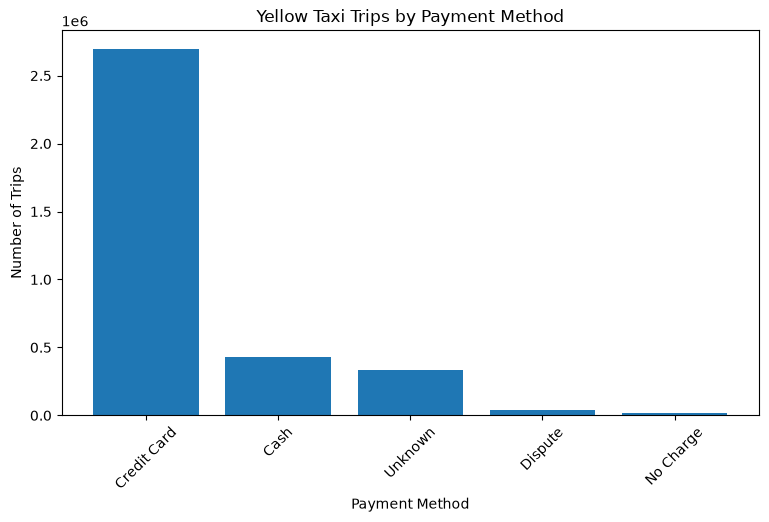

In [39]:
plt.figure(figsize=(9, 5))

plt.bar(payment_counts.index, payment_counts.values)

plt.title("Yellow Taxi Trips by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.show()

#### Interpretation

The visualisation shows that credit card payments are the most commonly recorded payment method for Yellow Taxi trips, accounting for considerably more journeys than the other payment categories. Cash is the second most frequently recorded payment method, while no-charge and disputed trips represent only a small proportion of the dataset.

This indicates that electronic card payments play a dominant role in Yellow Taxi transactions. From a business perspective, the strong use of credit cards highlights the importance of maintaining reliable electronic payment systems and providing customers with convenient digital payment options.

The small number of disputed and no-charge journeys also suggests that these transaction types represent only a minor part of overall taxi activity.

###  Insight 6: Do Tip Amounts Differ by Trip Distance?

Tipping represents an additional financial component of taxi journeys and can provide insight into passenger behaviour. This analysis compares the distribution of recorded tip amounts across different trip-distance groups.

Trips are divided into four distance categories to make the comparison easier to interpret. As previously identified extreme values could distort the visualisation, the analysis focuses on trip distances and tip amounts within the selected ranges.

In [40]:
df_clean["tip_amount"].describe()

count    3.511771e+06
mean     3.397177e+00
std      4.019634e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.720000e+00
75%      4.340000e+00
max      5.725000e+02
Name: tip_amount, dtype: float64

In [41]:
tip_99 = df_clean["tip_amount"].quantile(0.99)

tip_99

np.float64(17.6)

In [42]:
tip_box_data = df_clean[
    (df_clean["trip_distance"] > 0) &
    (df_clean["trip_distance"] <= distance_99) &
    (df_clean["tip_amount"] >= 0) &
    (df_clean["tip_amount"] <= tip_99)
].copy()

tip_box_data["distance_group"] = pd.cut(
    tip_box_data["trip_distance"],
    bins=[0, 3, 6, 10, 20],
    labels=["0-3 miles", "3-6 miles", "6-10 miles", "10-20 miles"]
)

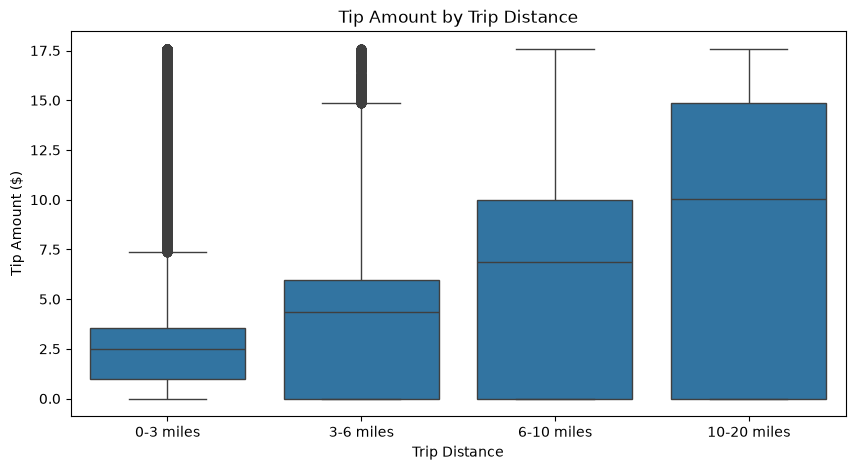

In [43]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=tip_box_data,
    x="distance_group",
    y="tip_amount"
)

plt.title("Tip Amount by Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Tip Amount ($)")

plt.show()

#### Interpretation


The box plot shows that recorded tip amounts generally increase as trip distance increases. Trips between 0–3 miles have the lowest median tip at approximately $2.50, while the median rises to around $4 for trips between 3–6 miles and approximately $7 for trips between 6–10 miles. Trips between 10–20 miles have the highest median tip at approximately $10.

The spread of tip amounts also becomes wider for longer journeys, indicating greater variation in tipping behaviour. In addition, several distance groups include trips with a recorded tip of $0, showing that longer distance does not always result in a higher tip.

Overall, the visualisation suggests a positive association between trip distance and recorded tip amount. From a business perspective, longer journeys appear to provide greater potential for higher tips, although tipping behaviour still varies considerably between individual trips.

### Insight 7: How Does Average Fare Change Throughout the Day?

While the earlier analysis identified how taxi demand changes throughout the day, trip volume alone does not describe the financial characteristics of those journeys. This analysis examines the average fare amount at each hour of the day to determine whether trips taken at certain times tend to have higher fares.

To reduce the influence of previously identified extreme fare values, the analysis uses fare amounts within the 99th percentile range.

In [44]:
hourly_fare_data = df_clean[df_clean["fare_amount"] <= fare_99]

average_fare_by_hour = hourly_fare_data.groupby("pickup_hour")["fare_amount"].mean()

average_fare_by_hour

pickup_hour
0     18.457518
1     16.465846
2     15.671352
3     16.690096
4     21.249069
5     25.382124
6     21.043611
7     18.592533
8     17.891648
9     17.814385
10    18.224090
11    18.523239
12    19.111625
13    19.732197
14    20.416203
15    20.140361
16    20.271082
17    19.066367
18    17.757552
19    18.290811
20    18.725521
21    18.400279
22    18.680371
23    19.226986
Name: fare_amount, dtype: float64

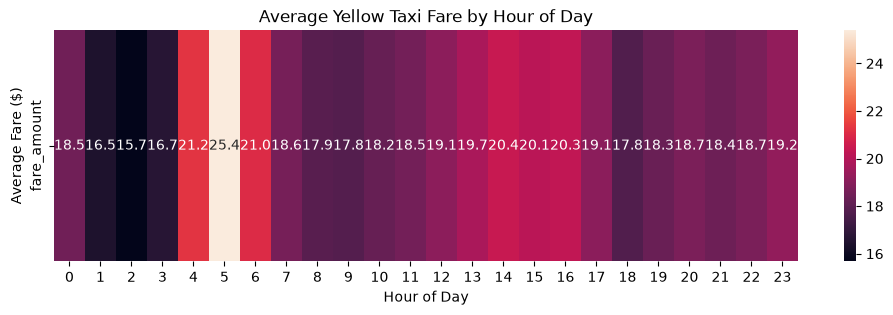

In [45]:
fare_heatmap = average_fare_by_hour.to_frame().T

plt.figure(figsize=(12, 3))

sns.heatmap(
    fare_heatmap,
    annot=True,
    fmt=".1f"
)

plt.title("Average Yellow Taxi Fare by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare ($)")

plt.show()

#### Interpretation

Average fare amounts vary across the hours of the day, although most hours remain within a relatively similar range. The most noticeable difference occurs during the early morning, with the average fare reaching its highest level at approximately 5:00 AM. In contrast, the lowest average fare is observed at around 2:00 AM.

For most daytime and evening hours, average fares remain relatively stable at approximately $18–$20. Interestingly, the highest average fare does not occur during the period of highest taxi demand. Insight 1 showed that trip activity peaks at around 6:00 PM, while the highest average fare occurs much earlier in the day.

This suggests that periods with the greatest number of trips do not necessarily produce the highest fare per individual journey. From a business perspective, taxi operators should therefore consider both trip volume and average trip value when evaluating activity across different periods of the day.

## STEP 4: DISCUSSIONS AND CONCLUSIONS


### 4.1 Summary of Key Findings

The analysis found that Yellow Taxi activity varies considerably depending on time and day. Hourly demand was lowest during the early morning and increased throughout the day, reaching its highest level at approximately 6:00 PM. Demand also varied across the week, with Saturday recording the highest number of trips, followed by Friday.

Trip-distance analysis showed that the majority of journeys were relatively short, with trips strongly concentrated around 1–3 miles. A positive relationship was also observed between trip distance and fare amount, indicating that longer journeys generally resulted in higher fares.

Credit cards were the most commonly recorded payment method, followed by cash, while other payment categories represented a much smaller proportion of trips. The tipping analysis also showed a general tendency for higher recorded tips on longer journeys, although considerable variation was present and many journeys recorded no tip.

Finally, average fare amounts varied by hour. The highest average fare was observed during the early morning at approximately 5:00 AM, whereas the highest trip volume occurred at approximately 6:00 PM. This demonstrates that periods of high demand do not necessarily correspond with the highest average fare per journey.

### 4.2 Strengths and Limitations

A key strength of this analysis is the large number of taxi journeys available in the dataset, allowing patterns to be examined across millions of observations. The analysis also followed a structured process of initial exploration, data-quality investigation, preprocessing, visualisation, and interpretation. Potentially problematic records, including invalid distances, negative fares, dates outside the selected month, and extreme values, were considered before constructing the final visualisations.

Another strength is the use of different visualisation types according to the characteristics of the data. A line chart was used to examine hourly taxi demand, bar charts were used for categorical comparisons, and a histogram was used to examine the distribution of trip distances. A scatter plot was used to investigate the relationship between trip distance and fare amount, while a box plot was used to compare tip distributions across distance groups. A heatmap was also used to present differences in average fares across the hours of the day. This variety of visualisations allowed different characteristics and relationships within the dataset to be communicated appropriately.

However, the analysis also has limitations. It considers only November 2024, meaning that the findings cannot necessarily represent taxi behaviour throughout the entire year. Seasonal changes, holidays, weather, and other external factors may influence taxi demand but are not directly examined in this analysis.

Some variables also contain missing values, and extreme observations were identified within the dataset. The analysis limited extreme values in selected visualisations rather than assuming that every unusually large observation was invalid. In addition, recorded tip amounts may not represent all forms of tipping behaviour. Finally, the analysis identifies patterns and relationships within the data but does not establish the causes of those patterns.

### 4.3 Business Implications and Recommendations

The findings have several potential implications for Yellow Taxi operations. First, taxi demand is highest during the late afternoon and early evening, with the greatest number of trips occurring around 6:00 PM. Driver availability could therefore be planned to better reflect periods of higher demand.

The strong demand observed on Friday and Saturday provides another consideration for service planning. Greater vehicle and driver availability during these days may help taxi services respond to increased passenger demand.

The analysis also shows that short-distance journeys account for a large proportion of taxi activity. Operational planning should therefore consider the importance of frequent short journeys rather than focusing only on longer and higher-fare trips.

Credit cards are the dominant recorded payment method, highlighting the importance of reliable electronic payment facilities. Maintaining convenient and dependable card-payment systems can support the payment behaviour already observed among passengers.

Finally, the difference between peak demand and peak average fare demonstrates that trip volume and average trip value provide different perspectives on taxi activity. Operational decisions should therefore consider multiple measures rather than relying on trip counts alone.

### 4.4 Conclusion

This project used exploratory analysis and data visualisation to examine NYC Yellow Taxi activity during November 2024. After investigating and preprocessing the dataset, seven insights were developed to communicate patterns relating to demand, trip distance, fares, payment methods, and tipping behaviour.

The results demonstrate that Yellow Taxi usage is strongly influenced by time and day, that shorter journeys make up a substantial proportion of taxi activity, and that trip distance is associated with both fares and recorded tips. The analysis also highlights the importance of considering different measures of performance, as the period with the highest demand did not produce the highest average fare per trip.

Overall, the visualisations provide a clear summary of important patterns within the November 2024 data and show how taxi trip records can support operational understanding and data-informed decision making. Further analysis using multiple months, location information, and additional external factors could provide a more complete understanding of Yellow Taxi activity over time.

## 5. References

New York City Taxi and Limousine Commission (NYC TLC) (2024) *TLC Trip Record Data*. 
[Available here](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) 
(Accessed: 12 September 2026).

New York City Taxi and Limousine Commission (NYC TLC) (2024) *Yellow Taxi Trip Records – November 2024*. 
[Dataset](https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-11.parquet) 
(Accessed: 12 September 2026).

McKinney, W. (2022) *Python for Data Analysis: Data Wrangling with pandas, NumPy, and Jupyter*. 3rd edn. Sebastopol, CA: O’Reilly Media.

Hunter, J.D. (2007) ‘Matplotlib: A 2D graphics environment’, *Computing in Science & Engineering*, 9(3), pp. 90–95.

Waskom, M.L. (2021) ‘Seaborn: Statistical data visualization’, *Journal of Open Source Software*, 6(60), p. 3021.